Download data

In [126]:
import pandas as pd
import numpy as np
import datetime as dt
import matplotlib.pyplot as plt
import missingno as msno
import dateutil as dtl
import seaborn as sns
from jupyter_core.version import parts
from scipy.signal import resample
import time
from functools import wraps
from statsmodels.formula.api import ols

# airlines_df = pd.read_csv('archive/airlines.csv')
# airports_df = pd.read_csv('archive/airports.csv')
flights_df = pd.read_csv('archive/flights.csv', dtype={'ORIGIN_AIRPORT':object,'DESTINATION_AIRPORT':object}, usecols=
                         ['YEAR','MONTH','DAY','FLIGHT_NUMBER','AIRLINE','ORIGIN_AIRPORT','DESTINATION_AIRPORT','FLIGHT_NUMBER','DEPARTURE_TIME','ARRIVAL_TIME','DEPARTURE_DELAY','DISTANCE','AIR_TIME','ARRIVAL_DELAY','CANCELLED','DIVERTED'])


Created functions and decorators

In [127]:
def timer(func):
    @wraps(func)
    def wrapper(*args, **kwargs):
        start = time.time()
        func(*args, **kwargs)
        print(time.time() - start)
    return wrapper



def to_time(row):
    if pd.isna(row):return np.nan
    if int(row)==2400: row = '00:00:00'
    else:
        row = "{0:04d}".format(int(row))
        row = dt.time(int(row[0:2]),int(row[2:4]))
    return row
flights_df['departure_time'] = flights_df['DEPARTURE_TIME'].apply(to_time)
flights_df.drop('DEPARTURE_TIME',axis=1,inplace=True)
print(flights_df['departure_time'])
print(flights_df['departure_time'].isna().sum())
flights_df['ARRIVAL_TIME'] = flights_df['ARRIVAL_TIME'].apply(to_time)
print(flights_df['ARRIVAL_TIME'].head())

0          23:54:00
1          00:02:00
2          00:18:00
3          00:15:00
4          00:24:00
             ...   
5819074    23:55:00
5819075    23:55:00
5819076    23:50:00
5819077    23:53:00
5819078    00:14:00
Name: departure_time, Length: 5819079, dtype: object
86153
0    04:08:00
1    07:41:00
2    08:11:00
3    07:56:00
4    02:59:00
Name: ARRIVAL_TIME, dtype: object


Explore missing values and check dtypes

In [3]:
print(flights_df.isna().sum())
print(flights_df.info())

YEAR                        0
MONTH                       0
DAY                         0
AIRLINE                     0
FLIGHT_NUMBER               0
ORIGIN_AIRPORT              0
DESTINATION_AIRPORT         0
DEPARTURE_DELAY         86153
AIR_TIME               105071
DISTANCE                    0
ARRIVAL_TIME            92513
ARRIVAL_DELAY          105071
DIVERTED                    0
CANCELLED                   0
departure_time          86153
dtype: int64
<class 'pandas.DataFrame'>
RangeIndex: 5819079 entries, 0 to 5819078
Data columns (total 15 columns):
 #   Column               Dtype  
---  ------               -----  
 0   YEAR                 int64  
 1   MONTH                int64  
 2   DAY                  int64  
 3   AIRLINE              str    
 4   FLIGHT_NUMBER        int64  
 5   ORIGIN_AIRPORT       object 
 6   DESTINATION_AIRPORT  object 
 7   DEPARTURE_DELAY      float64
 8   AIR_TIME             float64
 9   DISTANCE             int64  
 10  ARRIVAL_TIME         f

As we can see all columns which are related to the departure have the same amount of missing values. There must be a reason why we have such a big number of missing values. There's the same amount of missing values with arrival time(also there are less missing values in arrival_time which is a bit strange to see).

Having said all of that we might want to try to see whether all the missing values are related to a specific time(or moment). Another possible explanation is that a big chunk of missing values could be simply cancelled flights, because they hadn't departed.

<Axes: >

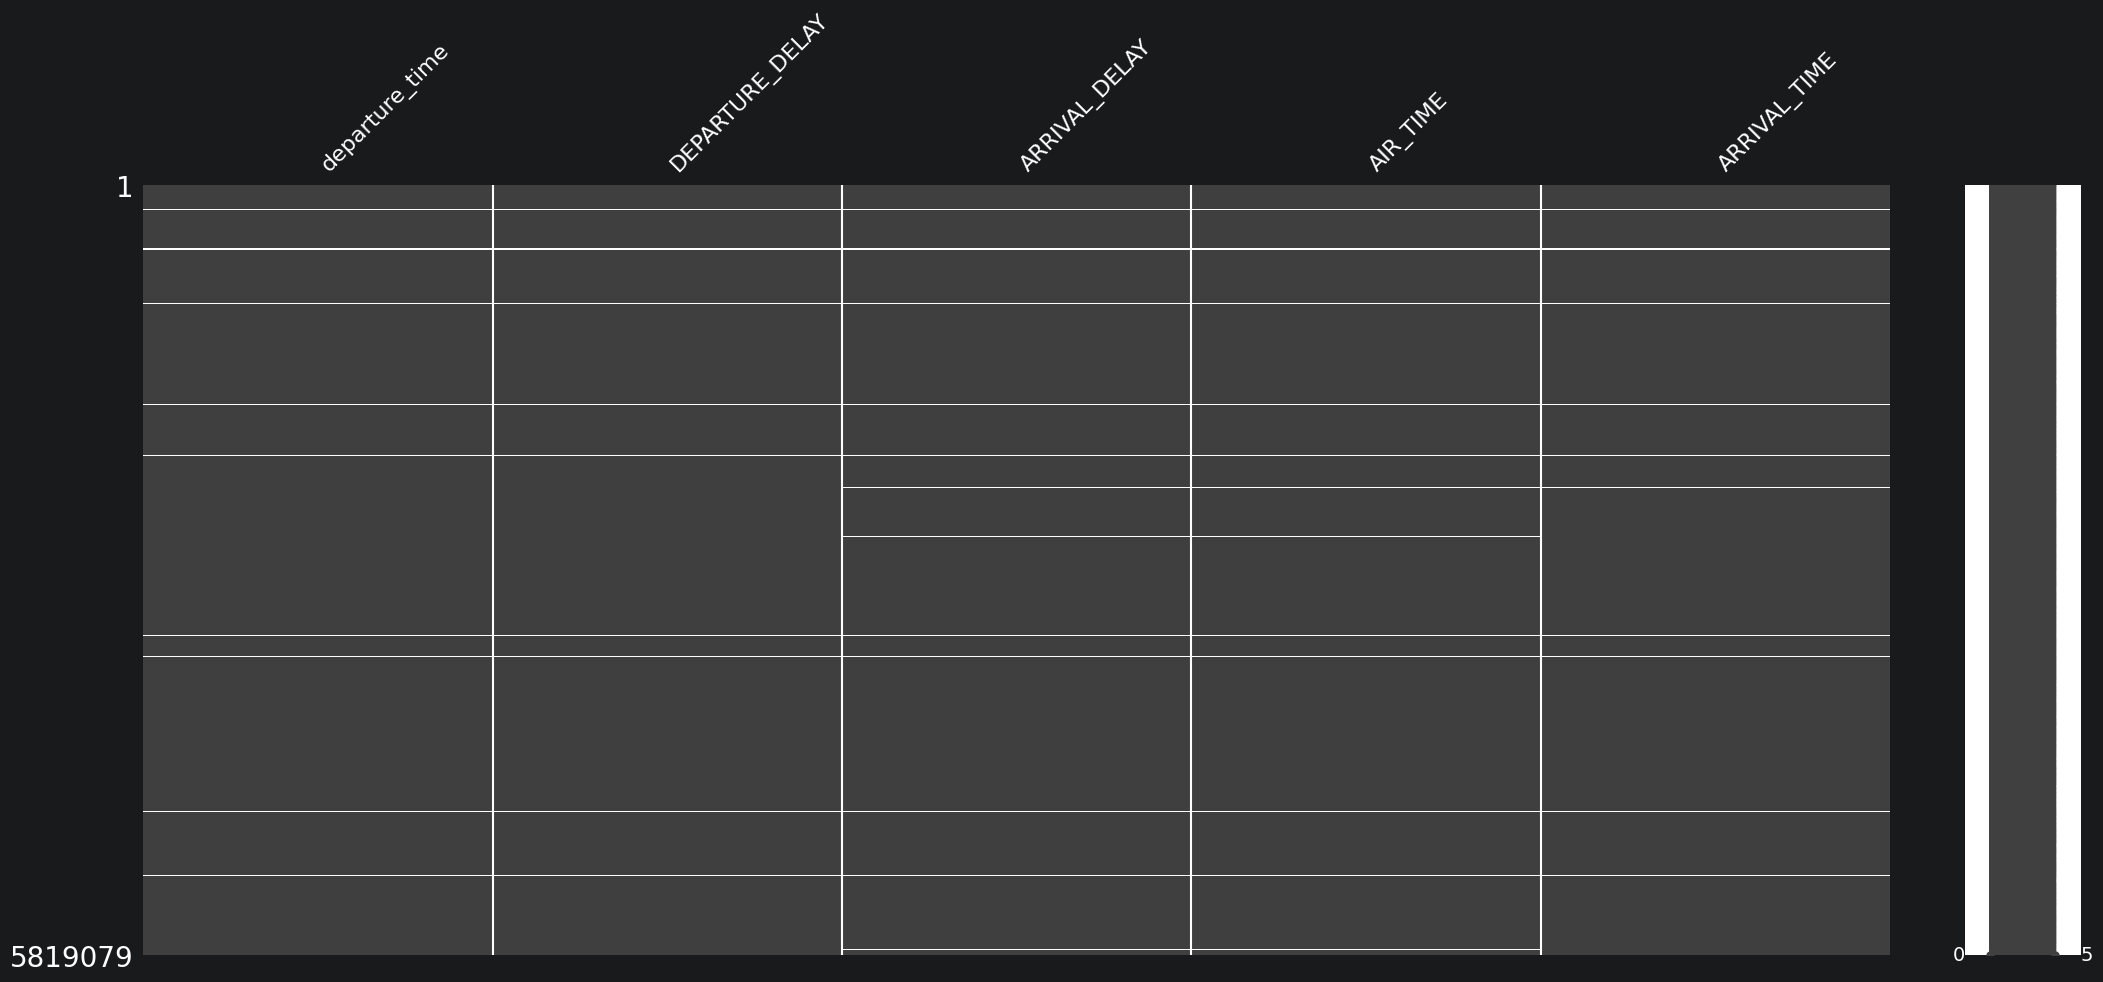

In [4]:
msno.matrix(flights_df[['departure_time','DEPARTURE_DELAY','ARRIVAL_DELAY','AIR_TIME','ARRIVAL_TIME']])

In [5]:
flights_df['CANCELLED'].sum()

np.int64(89884)

In [6]:
flights_df.loc[flights_df['CANCELLED']==1][['ARRIVAL_DELAY','ARRIVAL_TIME']].isna().sum()

ARRIVAL_DELAY    89884
ARRIVAL_TIME     89884
dtype: int64

As we can see there is a clear pattern for the most of the flights. And the number of canceled flights is really close to numbers of our missing values. I will assume that almost all missing values are due to the fact that flights were canceled. But still, there are some values that couldn't be described by only canceled flights. So let's check this flights and my theory.

In [7]:
flights_df.loc[flights_df['CANCELLED']==1,'departure_time'].isna().sum()

np.int64(86153)

Okay, so we proved that all missing values related to the departure are canceled flights, which is alright and we don't need to change them. The only srange thing here is that the number of canceled flights doesn't align with the number of missing values. Let's use value_counts() to see what is going on.

In [8]:
flights_df.loc[flights_df['CANCELLED']==1,'departure_time'].value_counts(dropna=False)

departure_time
NaN         86153
16:10:00       11
15:10:00       10
22:08:00       10
14:11:00       10
            ...  
11:47:00        1
21:13:00        1
00:31:00        1
22:36:00        1
22:45:00        1
Name: count, Length: 1098, dtype: int64

We can see that there are some strange values here in canceled flights for the departure time. I'm not really sure what might have caused them, but most likely it's just a mistake and we should make them nan(but for now let's keep them as they are).

A few words about arrival time and air_time with arrival_delay. Due to the matrix that we have built we can see that again, all the canceled flights are responsible for a majority of missing values(but not for all of them!). For some reason there are a few thousand of flights with missing values which are not related to the canceled flights. We need to know a lot more about our data to make any conclusions this time. A few options:
1. Drop missing values(there are not so many of them, around 20k for 5.6 million rows which corresponds to 0.3% of all the values. That is a good idea in our case.
2. Fill missing values(via forward fill, or any other filling method).
3. If possible, try to find out why those values were missed.
Out of all of those variants first one seems to be the best. The reason why is that all this missing values correspond to less than 1% of all values and most likely it wouldn't hurt our model our analysis just to drop them. It also saves a lot of time which we can spend on more important things.

In [16]:
flights_df[flights_df['DIVERTED']==1]

,YEAR,MONTH,DAY,AIRLINE,FLIGHT_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,DEPARTURE_DELAY,AIR_TIME,DISTANCE,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,departure_time
724,2015,1,1,DL,716,OMA,ATL,-8.0,NaN,821,1451.0,NaN,1,0,06:37:00
1455,2015,1,1,OO,5237,MKE,IAH,-3.0,NaN,984,1505.0,NaN,1,0,07:42:00
2218,2015,1,1,WN,1966,ATL,JAX,37.0,NaN,270,1219.0,NaN,1,0,09:22:00
2526,2015,1,1,EV,4555,IAH,HRL,-3.0,NaN,295,1319.0,NaN,1,0,08:59:00
2866,2015,1,1,WN,1081,MDW,OKC,-4.0,NaN,691,1343.0,NaN,1,0,09:26:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5813860,2015,12,31,UA,1291,LIH,LAX,296.0,NaN,2615,NaN,NaN,1,0,19:01:00
5815052,2015,12,31,EV,2785,DFW,BRO,25.0,NaN,482,NaN,NaN,1,0,15:55:00
5816657,2015,12,31,UA,291,IAD,SMF,5.0,NaN,2358,2216.0,NaN,1,0,17:40:00
5817342,2015,12,31,MQ,3060,DFW,FAR,10.0,NaN,968,2250.0,NaN,1,0,18:40:00


One more thing, all diverted flights have a None in the AIR_TIME columns, this explains yet again a great deal of our missing values. Last check is let's look at missing values that aren't realted to a flight type(CANCELED OR DIVERTED)

In [17]:
flights_df.loc[(flights_df['CANCELLED']==0) & (flights_df['DIVERTED']==0)].isna().sum()

YEAR                   0
MONTH                  0
DAY                    0
AIRLINE                0
FLIGHT_NUMBER          0
ORIGIN_AIRPORT         0
DESTINATION_AIRPORT    0
DEPARTURE_DELAY        0
AIR_TIME               0
DISTANCE               0
ARRIVAL_TIME           0
ARRIVAL_DELAY          0
DIVERTED               0
CANCELLED              0
departure_time         0
dtype: int64

Finally, we can clearly see that actually all this time there were no missing values! AS all of them were naturally related to either diverted or canceled flights.

In [180]:
numeric_cols = ['DEPARTURE_DELAY','ARRIVAL_DELAY','AIR_TIME','DISTANCE','DIVERTED','CANCELLED']
flights_df[numeric_cols].describe()

,DEPARTURE_DELAY,ARRIVAL_DELAY,AIR_TIME,DISTANCE,DIVERTED,CANCELLED
count,5.732926e+06,5.714008e+06,5.714008e+06,5.819079e+06,5.819079e+06,5.819079e+06
mean,9.370158e+00,4.407057e+00,1.135116e+02,8.223565e+02,2.609863e-03,1.544643e-02
std,3.708094e+01,3.927130e+01,7.223082e+01,6.077843e+02,5.102012e-02,1.233201e-01
min,-8.200000e+01,-8.700000e+01,7.000000e+00,2.100000e+01,0.000000e+00,0.000000e+00
25%,-5.000000e+00,-1.300000e+01,6.000000e+01,3.730000e+02,0.000000e+00,0.000000e+00
50%,-2.000000e+00,-5.000000e+00,9.400000e+01,6.470000e+02,0.000000e+00,0.000000e+00
75%,7.000000e+00,8.000000e+00,1.440000e+02,1.062000e+03,0.000000e+00,0.000000e+00
max,1.988000e+03,1.971000e+03,6.900000e+02,4.983000e+03,1.000000e+00,1.000000e+00


Thanks to the describe method we can see that there may be a few outliers in AIR_TIME and DEPARTURE_DELAY columns. It won't do any harm to check DISTANCE column as well.

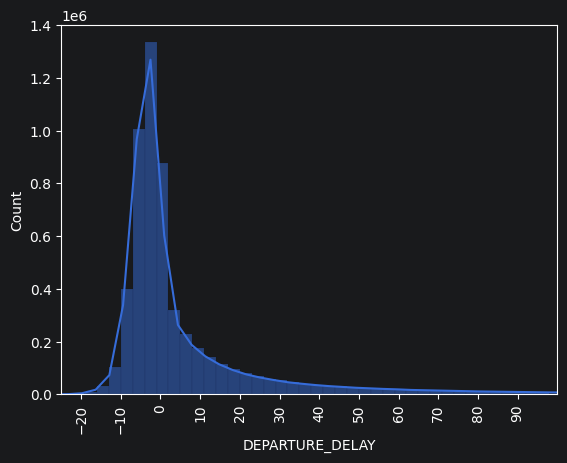

In [10]:
sns.histplot(flights_df['DEPARTURE_DELAY'],bins=range(-25,100,3),
             kde=True, kde_kws={'bw_adjust':0.6,'gridsize':600})
plt.xticks(range(-20,100,10),rotation=90)
plt.xlim(-25,100)
plt.show()

This distribution has a resemblance with a normal distribution. At least a little.

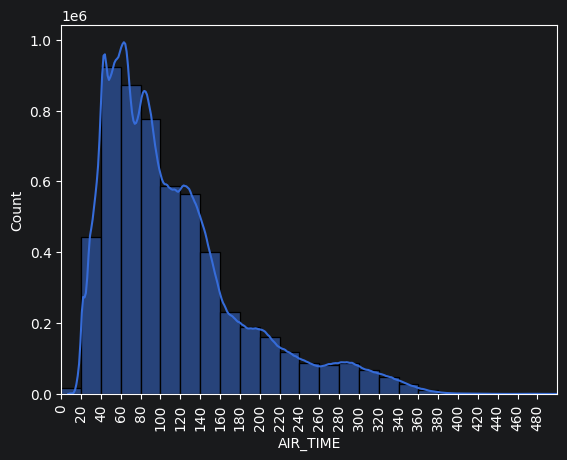

In [11]:
sns.histplot(flights_df['AIR_TIME'],bins=range(0,500,20),
             kde=True, kde_kws={'bw_adjust':0.3,'gridsize':500})
plt.xticks(range(0,500,20),rotation=90)
plt.xlim(0,500)
plt.show()

This distribution has a bit of resemblance with X^2 distribution.

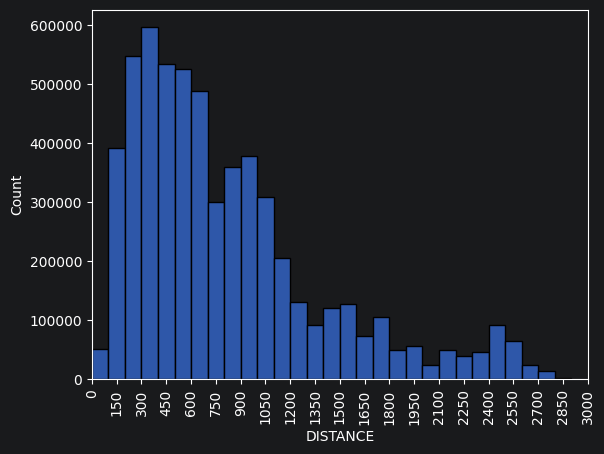

In [12]:
sns.histplot(flights_df['DISTANCE'],bins=range(0,3000,100))
plt.xticks(range(0,3001,150),rotation=90)
plt.xlim(0,3001)
plt.show()
# ,kde=True, kde_kws={'bw_adjust':0.3,'gridsize':500}

Again X^2

In [18]:
flights_df.columns

Index(['YEAR', 'MONTH', 'DAY', 'AIRLINE', 'FLIGHT_NUMBER', 'ORIGIN_AIRPORT',
       'DESTINATION_AIRPORT', 'DEPARTURE_DELAY', 'AIR_TIME', 'DISTANCE',
       'ARRIVAL_TIME', 'ARRIVAL_DELAY', 'DIVERTED', 'CANCELLED',
       'departure_time'],
      dtype='str')

In [151]:
new_df = flights_df.copy()

In [152]:
datetime_cols = ['YEAR','MONTH','DAY']
new_df[datetime_cols] = new_df[datetime_cols].astype('str')
new_df['EXACT_DATE'] = new_df['YEAR'].str.cat(others=new_df[['MONTH','DAY']], sep=':',na_rep='NaN')
new_df['EXACT_DATE']

0            2015:1:1
1            2015:1:1
2            2015:1:1
3            2015:1:1
4            2015:1:1
              ...    
5819074    2015:12:31
5819075    2015:12:31
5819076    2015:12:31
5819077    2015:12:31
5819078    2015:12:31
Name: EXACT_DATE, Length: 5819079, dtype: str

In [153]:
def to_date(row):
    if row == 'NaN':
        return 'NaN'
    parts = row.split(':')
    return f"{int(parts[0]):02d}:{int(parts[1]):02d}:{int(parts[2]):02d}"

new_df['EXACT_DATE'] = new_df['EXACT_DATE'].apply(to_date)
new_df['EXACT_DATE']

0          2015:01:01
1          2015:01:01
2          2015:01:01
3          2015:01:01
4          2015:01:01
              ...    
5819074    2015:12:31
5819075    2015:12:31
5819076    2015:12:31
5819077    2015:12:31
5819078    2015:12:31
Name: EXACT_DATE, Length: 5819079, dtype: str

In [154]:
new_df.drop(columns=['YEAR','MONTH','DAY'],inplace=True)
new_df.head()

,AIRLINE,FLIGHT_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,DEPARTURE_DELAY,AIR_TIME,DISTANCE,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,departure_time,EXACT_DATE
0,AS,98,ANC,SEA,-11.0,169.0,1448,04:08:00,-22.0,0,0,23:54:00,2015:01:01
1,AA,2336,LAX,PBI,-8.0,263.0,2330,07:41:00,-9.0,0,0,00:02:00,2015:01:01
2,US,840,SFO,CLT,-2.0,266.0,2296,08:11:00,5.0,0,0,00:18:00,2015:01:01
3,AA,258,LAX,MIA,-5.0,258.0,2342,07:56:00,-9.0,0,0,00:15:00,2015:01:01
4,AS,135,SEA,ANC,-1.0,199.0,1448,02:59:00,-21.0,0,0,00:24:00,2015:01:01


I dropped columns that aren't needed for this analysis (it is important to note that although I dropped those columns they are still present in the original dataframe, so we can use them later anytime).

Now I want to check all the datatypes and change them if there's a need.

In [155]:
new_df.dtypes

AIRLINE                    str
FLIGHT_NUMBER            int64
ORIGIN_AIRPORT          object
DESTINATION_AIRPORT     object
DEPARTURE_DELAY        float64
AIR_TIME               float64
DISTANCE                 int64
ARRIVAL_TIME            object
ARRIVAL_DELAY          float64
DIVERTED                 int64
CANCELLED                int64
departure_time          object
EXACT_DATE                 str
dtype: object

In [156]:
new_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5819079 entries, 0 to 5819078
Data columns (total 13 columns):
 #   Column               Dtype  
---  ------               -----  
 0   AIRLINE              str    
 1   FLIGHT_NUMBER        int64  
 2   ORIGIN_AIRPORT       object 
 3   DESTINATION_AIRPORT  object 
 4   DEPARTURE_DELAY      float64
 5   AIR_TIME             float64
 6   DISTANCE             int64  
 7   ARRIVAL_TIME         object 
 8   ARRIVAL_DELAY        float64
 9   DIVERTED             int64  
 10  CANCELLED            int64  
 11  departure_time       object 
 12  EXACT_DATE           str    
dtypes: float64(3), int64(4), object(4), str(2)
memory usage: 577.1+ MB


In [157]:
new_df['DEPARTURE_DELAY'] = np.where(new_df['DEPARTURE_DELAY'].isna(),0,new_df['DEPARTURE_DELAY'])
new_df['DISTANCE'] = np.where(new_df['DISTANCE'].isna(),0,new_df['DISTANCE'])
new_df['AIR_TIME'] = np.where(new_df['AIR_TIME'].isna(),0,new_df['AIR_TIME'])
new_df['ARRIVAL_DELAY'] = np.where(new_df['ARRIVAL_DELAY'].isna(),0,new_df['ARRIVAL_DELAY'])

In [170]:
dict_types = {'ORIGIN_AIRPORT':'category','DESTINATION_AIRPORT':'category','DIVERTED':'bool','CANCELLED':'bool',
              'departure_time':'str','DEPARTURE_DELAY':'int16', 'DISTANCE':'int16', 'AIR_TIME':'int16','ARRIVAL_DELAY':'int16','FLIGHT_NUMBER':'int16','AIRLINE':'category'}
new_df = new_df.astype(dict_types)
new_df.head()

,AIRLINE,FLIGHT_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,DEPARTURE_DELAY,AIR_TIME,DISTANCE,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,departure_time,EXACT_DATE
0,AS,98,ANC,SEA,-11,169,1448,04:08:00,-22,False,False,23:54:00,2015:01:01
1,AA,2336,LAX,PBI,-8,263,2330,07:41:00,-9,False,False,00:02:00,2015:01:01
2,US,840,SFO,CLT,-2,266,2296,08:11:00,5,False,False,00:18:00,2015:01:01
3,AA,258,LAX,MIA,-5,258,2342,07:56:00,-9,False,False,00:15:00,2015:01:01
4,AS,135,SEA,ANC,-1,199,1448,02:59:00,-21,False,False,00:24:00,2015:01:01


One thing we might want to consider is whether we need to change types of float columns. Changing float columns into int columns in this dataset might save us quite a lot of space.

In [171]:
new_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5819079 entries, 0 to 5819078
Data columns (total 13 columns):
 #   Column               Dtype   
---  ------               -----   
 0   AIRLINE              category
 1   FLIGHT_NUMBER        int16   
 2   ORIGIN_AIRPORT       category
 3   DESTINATION_AIRPORT  category
 4   DEPARTURE_DELAY      int16   
 5   AIR_TIME             int16   
 6   DISTANCE             int16   
 7   ARRIVAL_TIME         object  
 8   ARRIVAL_DELAY        int16   
 9   DIVERTED             bool    
 10  CANCELLED            bool    
 11  departure_time       str     
 12  EXACT_DATE           str     
dtypes: bool(2), category(3), int16(5), object(1), str(2)
memory usage: 227.5+ MB


Just by choosing appropriate data types we achieved more than twice reduction in memory usage!

In [173]:
# new_df['departure_time'] = pd.to_datetime(new_df['departure_time'], format="%H:%M:%S")
# new_df['departure_time']

0         1900-01-01 23:54:00
1         1900-01-01 00:02:00
2         1900-01-01 00:18:00
3         1900-01-01 00:15:00
4         1900-01-01 00:24:00
                  ...        
5819074   1900-01-01 23:55:00
5819075   1900-01-01 23:55:00
5819076   1900-01-01 23:50:00
5819077   1900-01-01 23:53:00
5819078   1900-01-01 00:14:00
Name: departure_time, Length: 5819079, dtype: datetime64[us]

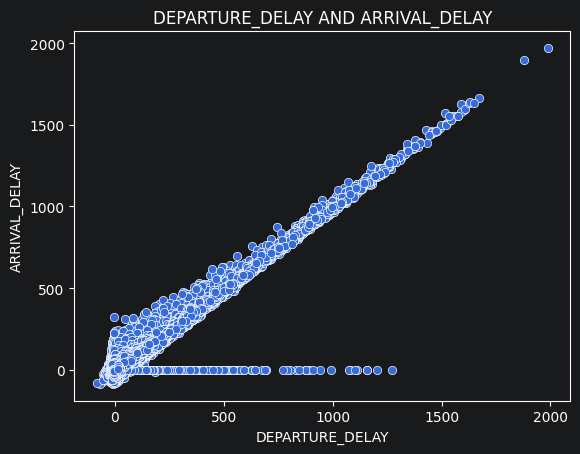

In [175]:
sns.scatterplot(data=new_df,x='DEPARTURE_DELAY',y='ARRIVAL_DELAY')
plt.title('DEPARTURE_DELAY AND ARRIVAL_DELAY')
plt.show()

Here we se that arrival delay almost always caused due to the departure delay. All the delays on the bottom are canceled and diverted flights.

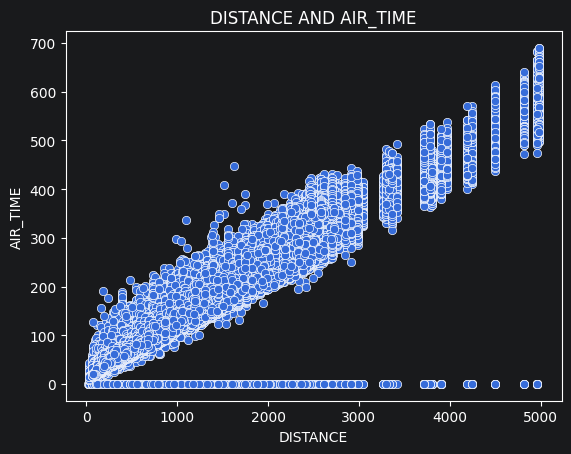

In [176]:
sns.scatterplot(data=new_df,x='DISTANCE',y='AIR_TIME')
plt.title('DISTANCE AND AIR_TIME')
plt.show()

Again we see that distance and time in the air are clearly linearly connected. Those vertical lines are most likely due to the fact that some flights might have worse conditions than others(due to a region location, weather, etc.)

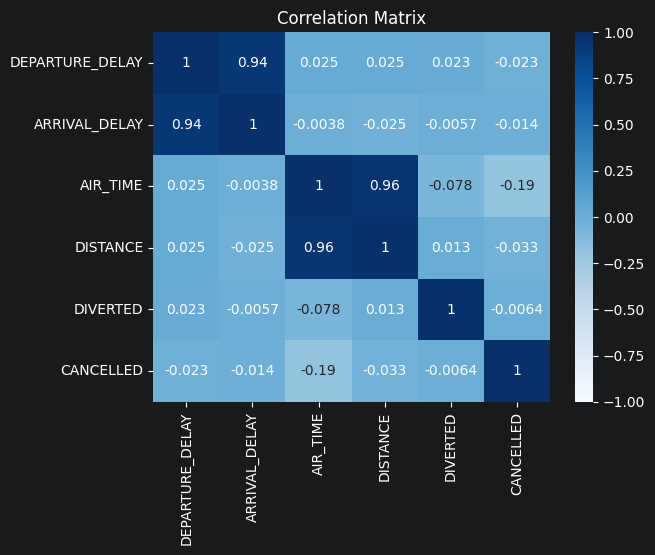

In [181]:
heat_matrix = new_df[numeric_cols].corr()
sns.heatmap(heat_matrix,vmin=-1,vmax=1, annot=True, cmap='Blues')
plt.title("Correlation Matrix")
plt.show()

Clearly, arrival delay and departure delay are very correlated. Other values doesn't have that much of correlation.